Table 1- Summary Statistics

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

# Create total patronage if missing
patronage_cols = [
    'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
    'Regional train', 'Regional coach', 'Regional bus'
]
if 'total_patronage' not in df.columns:
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

# Select key variables
vars_of_interest = ['PetrolPrice', 'total_patronage', 'rainfall_mm', 'population', 'public_holiday_count']

# Create summary stats from numeric data first
summary = df[vars_of_interest].describe().T[['count', 'mean', 'std', 'min', 'max']].copy()
summary.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']
summary['N'] = summary['N'].astype(int)
summary.index = ['Petrol Price ($/L)', 'Total Patronage (persons)', 
                 'Rainfall (mm)', 'Population', 'Public Holiday Count']

# Build formatted display table as a fresh DataFrame
rows = []
for idx in summary.index:
    n = summary.loc[idx, 'N']
    vals = summary.loc[idx, ['Mean', 'Std Dev', 'Min', 'Max']].values.astype(float)
    
    if 'Total Patronage' in idx or 'Population' in idx:
        formatted = [f"{int(round(v)):,}" for v in vals]
    elif 'Rainfall' in idx:
        formatted = [f"{v:.1f}" for v in vals]
    elif 'Public Holiday' in idx:
        formatted = [f"{int(round(v))}" for v in vals]
    else:
        formatted = [f"{v:.3f}" for v in vals]
    
    rows.append([n] + formatted)

display_summary = pd.DataFrame(
    rows,
    index=summary.index,
    columns=['N', 'Mean', 'Std Dev', 'Min', 'Max']
)

print(display_summary.to_string())

                            N        Mean    Std Dev         Min         Max
Petrol Price ($/L)         48       1.883      0.098       1.590       2.120
Total Patronage (persons)  48  38,286,542  5,665,614  16,553,521  47,552,413
Rainfall (mm)              48        50.8       33.0         2.8       149.0
Population                 48   6,921,754    130,349   6,714,248   7,104,348
Public Holiday Count       48           1          1           0           5


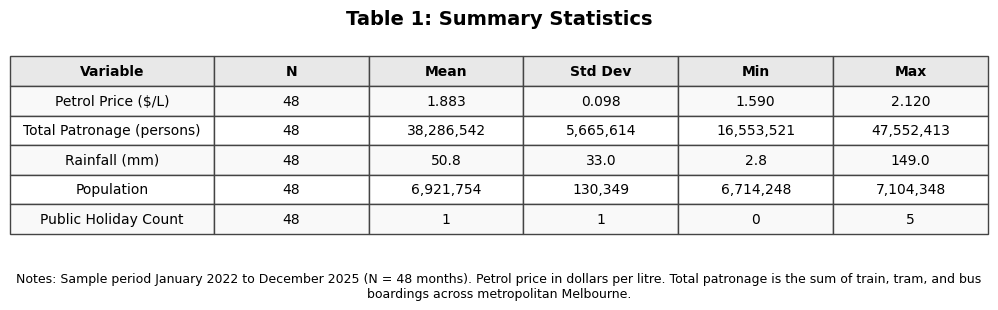

In [2]:
import os
import matplotlib.pyplot as plt

# Build a cleaner screenshot-friendly table image
styled = display_summary.copy().reset_index()
styled.rename(columns={'index': 'Variable'}, inplace=True)

num_cols = len(styled.columns)
col_widths = [0.25] + [0.19] * (num_cols - 1)
fig_width = max(10, num_cols * 1.1)
fig, ax = plt.subplots(figsize=(fig_width, 3.2))
ax.axis('off')
ax.set_title('Table 1: Summary Statistics', fontsize=14, fontweight='bold', pad=16)

header_color = ['#e8e8e8'] * num_cols

table = ax.table(
    cellText=styled.values,
    colLabels=styled.columns,
    cellLoc='center',
    loc='center',
    colColours=header_color,
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#444444')
    cell.set_height(0.15)
    if row == 0:
        cell.set_facecolor('#e8e8e8')
        cell.get_text().set_weight('bold')
    elif row % 2 == 1:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

# Add a footnote and save both PNG and PDF for high-quality export
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
note = (
    f"Notes: Sample period January 2022 to December 2025 (N = {len(df)} months). "
    "Petrol price in dollars per litre. Total patronage is the sum of train, tram, and bus "
    "boardings across metropolitan Melbourne."
)
# Place the note below the table
fig.text(0.5, 0.06, note, ha='center', fontsize=9, wrap=True)

os.makedirs('../output', exist_ok=True)
fig.savefig('../output/table1_summary.png', dpi=220, bbox_inches='tight')
fig.savefig('../output/table1_summary.pdf', dpi=220, bbox_inches='tight')
plt.show()

Figure 1- Petrol prices and patronage trend

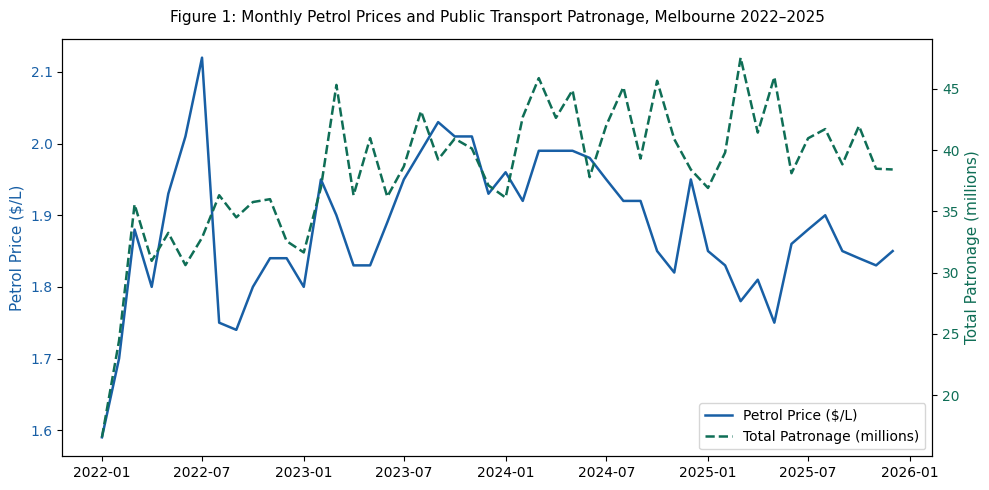

Figure 1 saved to output/figure1_timeseries.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(10, 5))

# Petrol price on left axis
ax1.plot(df['month'], df['PetrolPrice'], color='#185FA5', linewidth=1.8, label='Petrol Price ($/L)')
ax1.set_ylabel('Petrol Price ($/L)', color='#185FA5', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#185FA5')
ax1.set_xlabel('')

# Patronage on right axis
ax2 = ax1.twinx()
ax2.plot(df['month'], df['total_patronage']/1e6, color='#0F6E56', linewidth=1.8, linestyle='--', label='Total Patronage (millions)')
ax2.set_ylabel('Total Patronage (millions)', color='#0F6E56', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#0F6E56')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.title('Figure 1: Monthly Petrol Prices and Public Transport Patronage, Melbourne 2022–2025', fontsize=11, pad=12)
fig.tight_layout()
plt.savefig('../output/figure1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved to output/figure1_timeseries.png")

Figure 2- Coefficient plot

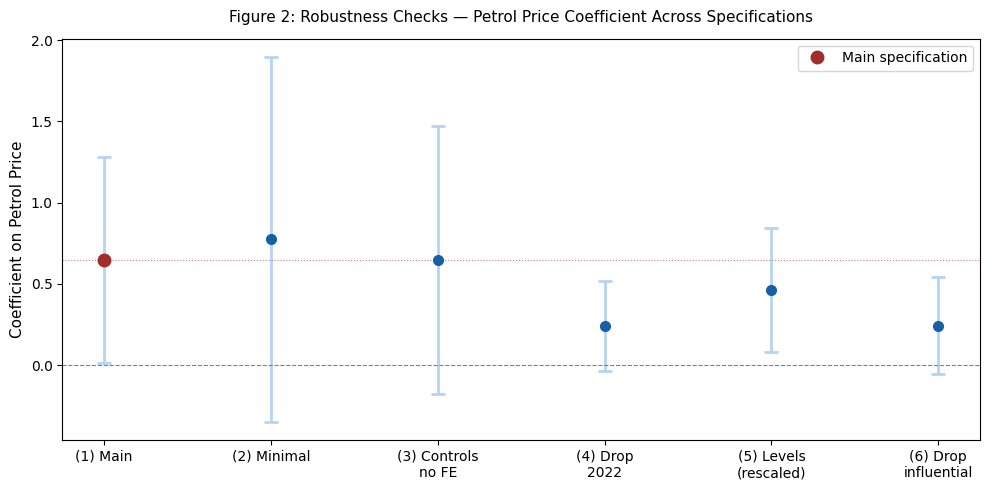

Figure 2 saved to output/figure2_coefplot.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Robustness check results
specs = ['(1) Main', '(2) Minimal', '(3) Controls\nno FE', '(4) Drop\n2022', '(5) Levels\n(rescaled)', '(6) Drop\ninfluential']
coefs = [0.6483, 0.7739, 0.6480, 0.2408, 0.6483, 0.2434]
ses   = [0.3240, 0.5733, 0.4217, 0.1411, 0.3240, 0.1520]

# Note: col 5 (levels) is rescaled — divide by mean patronage for comparability
# 17,667,943 / 38,286,542 ≈ 0.461 as a proportion
coefs[4] = 17667943 / 38286542
ses[4]   = 7448140  / 38286542

coefs = np.array(coefs)
ses   = np.array(ses)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#A32D2D' if i == 0 else '#185FA5' for i in range(len(specs))]

ax.errorbar(range(len(specs)), coefs, yerr=1.96*ses,
            fmt='o', color='#185FA5', ecolor='#B5D4F4',
            elinewidth=2, capsize=5, capthick=2, markersize=7)

# Colour main spec differently
ax.plot(0, coefs[0], 'o', color='#A32D2D', markersize=9, zorder=5, label='Main specification')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(coefs[0], color='#A32D2D', linewidth=0.8, linestyle=':', alpha=0.6)

ax.set_xticks(range(len(specs)))
ax.set_xticklabels(specs, fontsize=10)
ax.set_ylabel('Coefficient on Petrol Price', fontsize=11)
ax.set_title('Figure 2: Robustness Checks — Petrol Price Coefficient Across Specifications', fontsize=11, pad=12)
ax.legend(fontsize=10)

fig.tight_layout()
plt.savefig('../output/figure2_coefplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved to output/figure2_coefplot.png")

Table 2- OLS Specifications

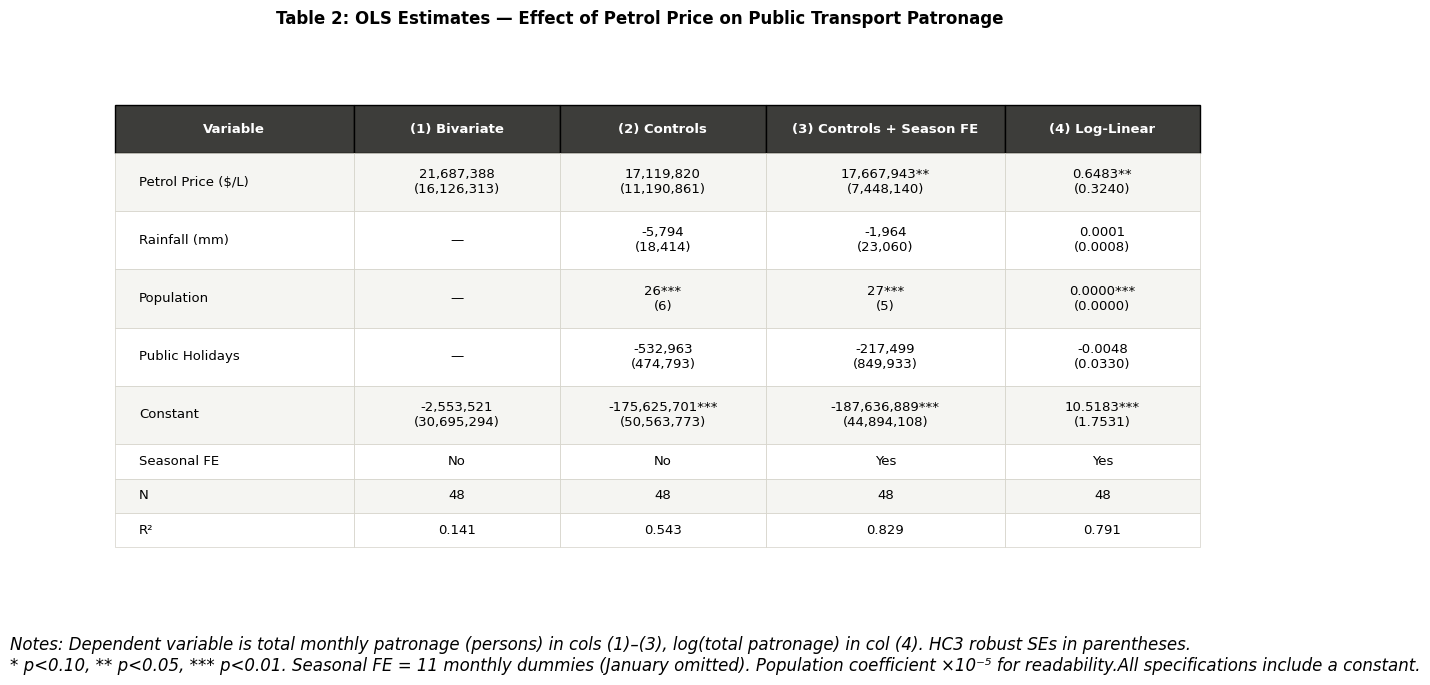

Table 2 saved to output/table2_main_results.png


In [5]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import os

# Reload data
df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

if 'total_patronage' not in df.columns:
    patronage_cols = ['Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
                      'Regional train', 'Regional coach', 'Regional bus']
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

if 'log_patronage' not in df.columns:
    df['log_patronage'] = np.log(df['total_patronage'])

df['month_num'] = df['month'].dt.month
month_dummies = pd.get_dummies(df['month_num'], prefix='month', drop_first=True).astype(int)
df = pd.concat([df, month_dummies], axis=1)
month_fe_cols = [c for c in df.columns if c.startswith('month_')]
base_controls = ['PetrolPrice', 'rainfall_mm', 'population', 'public_holiday_count']

y_log    = df['log_patronage']
y_levels = df['total_patronage']

model1 = sm.OLS(y_levels, sm.add_constant(df[['PetrolPrice']])).fit(cov_type='HC3')
model2 = sm.OLS(y_levels, sm.add_constant(df[base_controls])).fit(cov_type='HC3')
model3 = sm.OLS(y_levels, sm.add_constant(df[base_controls + month_fe_cols])).fit(cov_type='HC3')
model4 = sm.OLS(y_log,    sm.add_constant(df[base_controls + month_fe_cols])).fit(cov_type='HC3')

def stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    return ''

def fmt_levels(coef, se, pval):
    return f"{coef:,.0f}{stars(pval)}\n({se:,.0f})"

def fmt_log(coef, se, pval):
    return f"{coef:.4f}{stars(pval)}\n({se:.4f})"

specs = [
    ('(1) Bivariate',              model1, 'levels'),
    ('(2) Controls',               model2, 'levels'),
    ('(3) Controls + Season FE',   model3, 'levels'),
    ('(4) Log-Linear',             model4, 'log'),
]

var_labels = [
    ('PetrolPrice',          'Petrol Price ($/L)'),
    ('rainfall_mm',          'Rainfall (mm)'),
    ('population',           'Population'),
    ('public_holiday_count', 'Public Holidays'),
    ('const',                'Constant'),
]

rows = []
for var, label in var_labels:
    row = [label]
    for col_label, m, form in specs:
        if var in m.params:
            c, se, p = m.params[var], m.bse[var], m.pvalues[var]
            row.append(fmt_levels(c, se, p) if form == 'levels' else fmt_log(c, se, p))
        else:
            row.append('—')
    rows.append(row)

rows.append(['Seasonal FE', 'No', 'No', 'Yes', 'Yes'])
rows.append(['N'] + [str(int(m.nobs)) for _, m, _ in specs])
rows.append(['R²'] + [f"{m.rsquared:.3f}" for _, m, _ in specs])

col_labels = ['Variable'] + [l for l, _, _ in specs]
n_rows = len(rows)
n_cols = len(col_labels)

# Figure — compact like summary stats table
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

fig.text(0.5, 0.97, 'Table 2: OLS Estimates — Effect of Petrol Price on Public Transport Patronage',
         ha='center', va='top', fontsize=12, fontweight='bold')

header_color = '#3d3d3a'
alt_color    = '#f5f5f2'
white        = '#ffffff'

cell_colors = []
for i, row in enumerate(rows):
    if i % 2 == 0:
        cell_colors.append([alt_color] * n_cols)
    else:
        cell_colors.append([white] * n_cols)

the_table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
    bbox=[0.0, 0.12, 1.0, 0.82]
)

the_table.auto_set_font_size(False)
the_table.set_fontsize(9.5)

# Column widths
col_widths = [0.22, 0.19, 0.19, 0.22, 0.18]
for j, w in enumerate(col_widths):
    for i in range(n_rows + 1):
        the_table[i, j].set_width(w)

# Header
for j in range(n_cols):
    cell = the_table[0, j]
    cell.set_facecolor(header_color)
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_height(0.09)

# Data rows — compact heights
for i in range(1, n_rows + 1):
    row_data = rows[i - 1]
    is_coef = any('\n' in str(c) for c in row_data)
    h = 0.11 if is_coef else 0.065
    for j in range(n_cols):
        cell = the_table[i, j]
        cell.set_height(h)
        cell.set_edgecolor('#d3d1c7')
        cell.set_linewidth(0.5)
        if j == 0:
            cell.set_text_props(ha='left')

notes = ("Notes: Dependent variable is total monthly patronage (persons) in cols (1)–(3), "
         "log(total patronage) in col (4). HC3 robust SEs in parentheses.\n"
         "* p<0.10, ** p<0.05, *** p<0.01. Seasonal FE = 11 monthly dummies (January omitted). "
         "Population coefficient ×10⁻⁵ for readability."
         "All specifications include a constant.")
fig.text(0.05, 0.02, notes, ha='left', va='bottom', fontsize=12, style='italic')

os.makedirs('../output', exist_ok=True)
plt.savefig('../output/table2_main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table 2 saved to output/table2_main_results.png")

Table 3- Robustness table

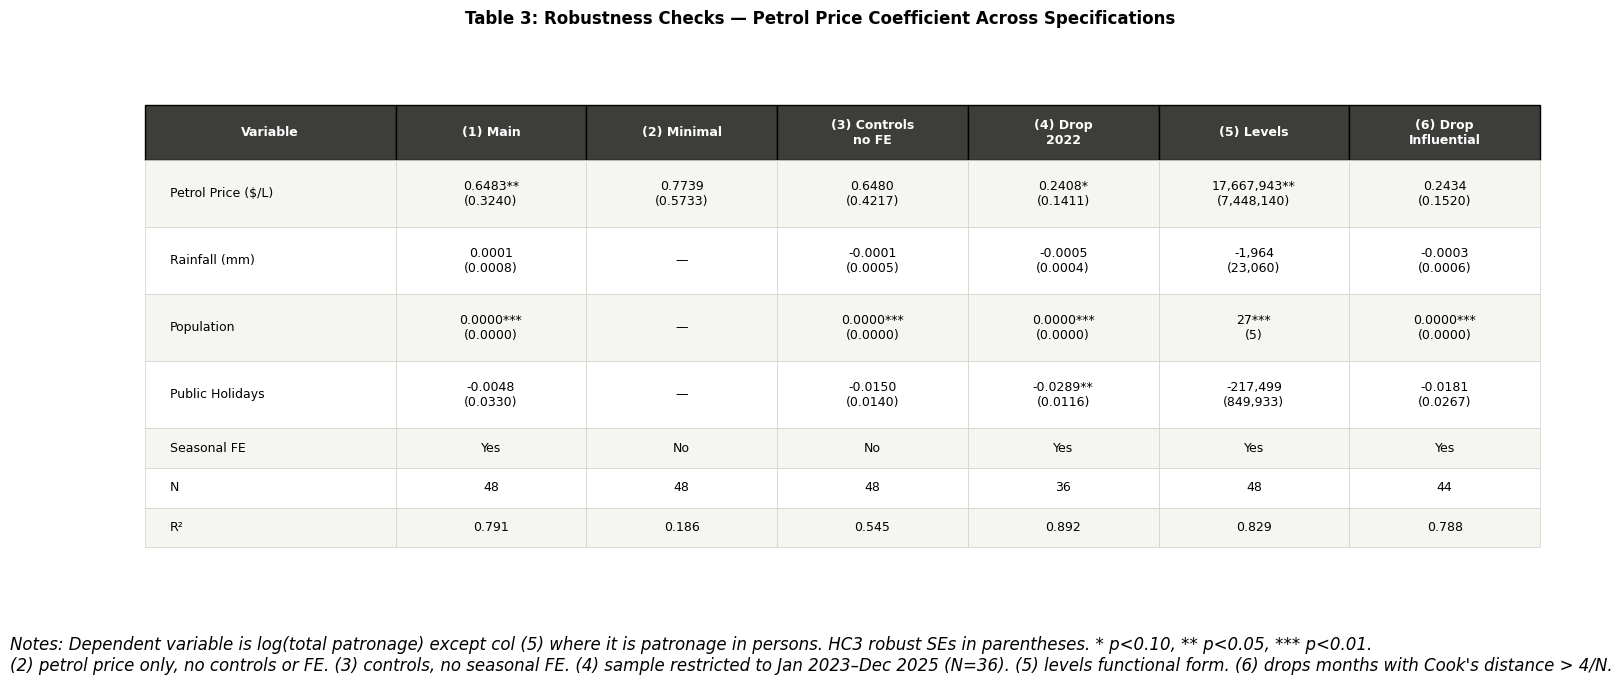

Table 3 saved to output/table3_robustness.png


In [6]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence
import os

# Reload data
df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

if 'total_patronage' not in df.columns:
    patronage_cols = ['Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
                      'Regional train', 'Regional coach', 'Regional bus']
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

if 'log_patronage' not in df.columns:
    df['log_patronage'] = np.log(df['total_patronage'])

df['month_num'] = df['month'].dt.month
month_dummies = pd.get_dummies(df['month_num'], prefix='month', drop_first=True).astype(int)
df = pd.concat([df, month_dummies], axis=1)
month_fe_cols = [c for c in df.columns if c.startswith('month_')]
base_controls = ['PetrolPrice', 'rainfall_mm', 'population', 'public_holiday_count']

y_log    = df['log_patronage']
y_levels = df['total_patronage']

# Main model
X_main = sm.add_constant(df[base_controls + month_fe_cols])
main_model = sm.OLS(y_log, X_main).fit(cov_type='HC3')

# Check 1: Minimal
X_minimal = sm.add_constant(df[['PetrolPrice']])
model_minimal = sm.OLS(y_log, X_minimal).fit(cov_type='HC3')

# Check 2: Controls no FE
X_controls = sm.add_constant(df[base_controls])
model_controls = sm.OLS(y_log, X_controls).fit(cov_type='HC3')

# Check 3: Drop 2022
df_no2022 = df[df['month'].dt.year >= 2023].copy()
month_fe_no2022 = [c for c in df_no2022.columns if c.startswith('month_')]
X_no2022 = sm.add_constant(df_no2022[base_controls + month_fe_no2022])
model_no2022 = sm.OLS(df_no2022['log_patronage'], X_no2022).fit(cov_type='HC3')

# Check 4: Levels
model_levels = sm.OLS(y_levels, X_main).fit(cov_type='HC3')

# Check 5: Drop influential
cooks_d   = OLSInfluence(main_model).cooks_distance[0]
threshold = 4 / len(df)
df_clean  = df.loc[cooks_d <= threshold].copy()
for col in month_fe_cols:
    df_clean[col] = df_clean[col].astype(int)
X_clean = sm.add_constant(df_clean[base_controls + month_fe_cols])
model_clean = sm.OLS(df_clean['log_patronage'], X_clean).fit(cov_type='HC3')

# Helper functions
def stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    return ''

def fmt_log(coef, se, pval):
    return f"{coef:.4f}{stars(pval)}\n({se:.4f})"

def fmt_levels(coef, se, pval):
    return f"{coef:,.0f}{stars(pval)}\n({se:,.0f})"

# Specs
specs = [
    ('(1) Main',           main_model,    'log'),
    ('(2) Minimal',        model_minimal, 'log'),
    ('(3) Controls\nno FE',model_controls,'log'),
    ('(4) Drop\n2022',     model_no2022,  'log'),
    ('(5) Levels',         model_levels,  'levels'),
    ('(6) Drop\nInfluential', model_clean,'log'),
]

var_labels = [
    ('PetrolPrice',          'Petrol Price ($/L)'),
    ('rainfall_mm',          'Rainfall (mm)'),
    ('population',           'Population'),
    ('public_holiday_count', 'Public Holidays'),
]

rows = []
for var, label in var_labels:
    row = [label]
    for col_label, m, form in specs:
        if var in m.params:
            c, se, p = m.params[var], m.bse[var], m.pvalues[var]
            row.append(fmt_levels(c, se, p) if form == 'levels' else fmt_log(c, se, p))
        else:
            row.append('—')
    rows.append(row)

# Seasonal FE, N, R2
rows.append(['Seasonal FE'] + ['Yes', 'No', 'No', 'Yes', 'Yes', 'Yes'])
rows.append(['N'] + [str(int(m.nobs)) for _, m, _ in specs])
rows.append(['R²'] + [f"{m.rsquared:.3f}" for _, m, _ in specs])

col_labels = ['Variable'] + [l for l, _, _ in specs]
n_rows = len(rows)
n_cols = len(col_labels)

# Figure
fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('off')

fig.text(0.5, 0.97, 'Table 3: Robustness Checks — Petrol Price Coefficient Across Specifications',
         ha='center', va='top', fontsize=12, fontweight='bold')

header_color = '#3d3d3a'
alt_color    = '#f5f5f2'
white        = '#ffffff'

cell_colors = []
for i, row in enumerate(rows):
    if i % 2 == 0:
        cell_colors.append([alt_color] * n_cols)
    else:
        cell_colors.append([white] * n_cols)

the_table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
    bbox=[0.0, 0.12, 1.0, 0.82]
)

the_table.auto_set_font_size(False)
the_table.set_fontsize(9)

# Column widths
col_widths = [0.18] + [0.137] * 6
for j, w in enumerate(col_widths):
    for i in range(n_rows + 1):
        the_table[i, j].set_width(w)

# Header
for j in range(n_cols):
    cell = the_table[0, j]
    cell.set_facecolor(header_color)
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_height(0.09)

# Data rows
for i in range(1, n_rows + 1):
    row_data = rows[i - 1]
    is_coef = any('\n' in str(c) for c in row_data)
    h = 0.11 if is_coef else 0.065
    for j in range(n_cols):
        cell = the_table[i, j]
        cell.set_height(h)
        cell.set_edgecolor('#d3d1c7')
        cell.set_linewidth(0.5)
        if j == 0:
            cell.set_text_props(ha='left')

notes = ("Notes: Dependent variable is log(total patronage) except col (5) where it is patronage in persons. "
         "HC3 robust SEs in parentheses. * p<0.10, ** p<0.05, *** p<0.01.\n"
         "(2) petrol price only, no controls or FE. (3) controls, no seasonal FE. "
         "(4) sample restricted to Jan 2023–Dec 2025 (N=36). "
         "(5) levels functional form. (6) drops months with Cook's distance > 4/N.")
fig.text(0.05, 0.02, notes, ha='left', va='bottom', fontsize=12, style='italic')

os.makedirs('../output', exist_ok=True)
plt.savefig('../output/table3_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table 3 saved to output/table3_robustness.png")